# LaDiff – `BaseLimitedAngleReconstructions` Dataset Demo

This notebook demonstrates the `BaseLimitedAngleReconstructions` dataset introduced
for the **ladiff** project.  The dataset builds FBP reconstructions by sliding a window
of length `total_projections` (1501) over the temporally-assembled combined sinogram
`total_sino` (shape `K_ANGLES × N_SLICES`, W) and running 2-D parallel-beam FBP.

**Sections**
1. Imports & parameters
2. Instantiate the dataset
3. Inspect `total_sino` and `total_angles`
4. Visualise FBP reconstructions for selected window positions

## 1. Imports & parameters

In [5]:
import sys, importlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

import lovely_tensors as lt
lt.monkey_patch()

# ── Path setup ────────────────────────────────────────────────────────────
project_root = Path('/myhome/sdate')
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')

# Reload to pick up edits without restarting the kernel
import sdate.limited_angle_tomo as _lat_mod
importlib.reload(_lat_mod)

from sdate.limited_angle_tomo import BaseLimitedAngleReconstructions
from inct.dataset_slices import ProjectionSliceDataset

# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')
# ── Reconstruction (2D parallel beam via lamino with angle=0) ─────────────
from astra_torch.lamino import (
    fbp_reconstruction_masked,
    gd_reconstruction_masked,
    build_lamino_projector,
)

print('✅ Imports ready')
print(f'CUDA available: {torch.cuda.is_available()}')

✅ Imports ready
CUDA available: True


In [6]:
# ── Data ──────────────────────────────────────────────────────────────────
FILE_IDX = 1
DATA_PATH        = Path(f'/myhome/data/sdate/shared/compression_paper/small/file_{FILE_IDX}_extracted')
DOWNSCALE_FACTOR = 2.0


dataset_probe = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=1,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=False,
)

TARGET_SIZE = (dataset_probe.volume.shape[1], dataset_probe.volume.shape[0])
TARGET_SIZE = tuple(int(x // DOWNSCALE_FACTOR) for x in TARGET_SIZE)
# TARGET_SIZE = (int(TARGET_SIZE[0] // DOWNSCALE_FACTOR), TARGET_SIZE[1])  # Make it square for simplicity
TARGET_SIZE

NUM_PROJECTIONS = dataset_probe.processor.num_projections

print(f'DATA_PATH   : {DATA_PATH}')
print(f'window_size : {NUM_PROJECTIONS}  (= len(all_angles_deg))')
print(f'target_size : {TARGET_SIZE}')

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 1280 x 1080
   Use attenuation: False
ProjectionSliceDataset:
  Volume shape: (1080, 1280, 1)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,382,400
Loading 1 projections...
Volume shape: (1080, 1280, 1)
Total voxels: 1,382,400
Value range: [8927.0000, 46558.0000]
DATA_PATH   : /myhome/data/sdate/shared/compression_paper/small/file_1_extracted
window_size : 1501  (= len(all_angles_deg))
target_size : (640, 540)


## 2. Instantiate the dataset

`BaseLimitedAngleReconstructions.__init__` loads the full projection volume,
builds `LimitedAngleDataset`, and assembles `total_sino` / `total_angles`.
FBP is performed lazily in `__getitem__`.

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 1280 x 1080
   Use attenuation: True
🔬 Loading dark and flat field images...


Loading flats: 100%|██████████| 100/100 [00:11<00:00,  8.50it/s]


   Dark average range: [82.00, 489.50]
   Flat average range: [31784.50, 48300.00]
ProjectionSliceDataset:
  Volume shape: (540, 640, 1501)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 345,600
Loading 1501 projections...
  Loaded 50/1501
  Loaded 100/1501
  Loaded 150/1501
  Loaded 200/1501
  Loaded 250/1501
  Loaded 300/1501
  Loaded 350/1501
  Loaded 400/1501
  Loaded 450/1501
  Loaded 500/1501
  Loaded 550/1501
  Loaded 600/1501
  Loaded 650/1501
  Loaded 700/1501
  Loaded 750/1501
  Loaded 800/1501
  Loaded 850/1501
  Loaded 900/1501
  Loaded 950/1501
  Loaded 1000/1501
  Loaded 1050/1501
  Loaded 1100/1501
  Loaded 1150/1501
  Loaded 1200/1501
  Loaded 1250/1501
  Loaded 1300/1501
  Loaded 1350/1501
  Loaded 1400/1501
  Loaded 1450/1501
  Loaded 1500/1501
Volume shape: (540, 640, 1501)
Total voxels: 518,745,600
Value range: [-0.1236, 1.7032]


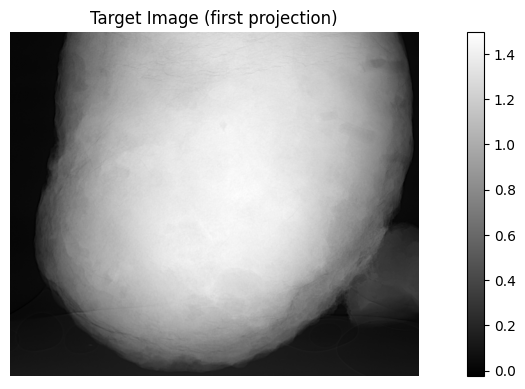

tensor[1501, 540, 640] n=518745600 (1.9Gb) x∈[-0.124, 1.703] μ=0.802 σ=0.512

In [7]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=True,
)

# Extract the first projection as the target 2D image
projections = dataset.get_full_volume().permute(2, 0, 1)  # (H, W, D)

plt.figure(figsize=(10, 4))
plt.imshow(projections[0].cpu().numpy(), cmap='gray')
plt.title('Target Image (first projection)')
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()


projections



In [8]:
# ANGULAR_RANGE_FRAC = 0.6

ANGULAR_RANGE_FRAC = 0.4
ANGULAR_RANGE = int(ANGULAR_RANGE_FRAC * NUM_PROJECTIONS)  # ANGULAR_RANGE_FRAC% of the projections

START_IDX = 0
DET_SPACING_MM = 1.0
LAMINO_ANGLE_DEG = 0.0

full_angles_deg = -1 * torch.linspace(0, 180, NUM_PROJECTIONS).numpy()
full_angles_deg -= 90 * (1 - ANGULAR_RANGE_FRAC)

la_projections = projections[START_IDX:START_IDX + ANGULAR_RANGE]
la_angles_deg = full_angles_deg[START_IDX:START_IDX + ANGULAR_RANGE]

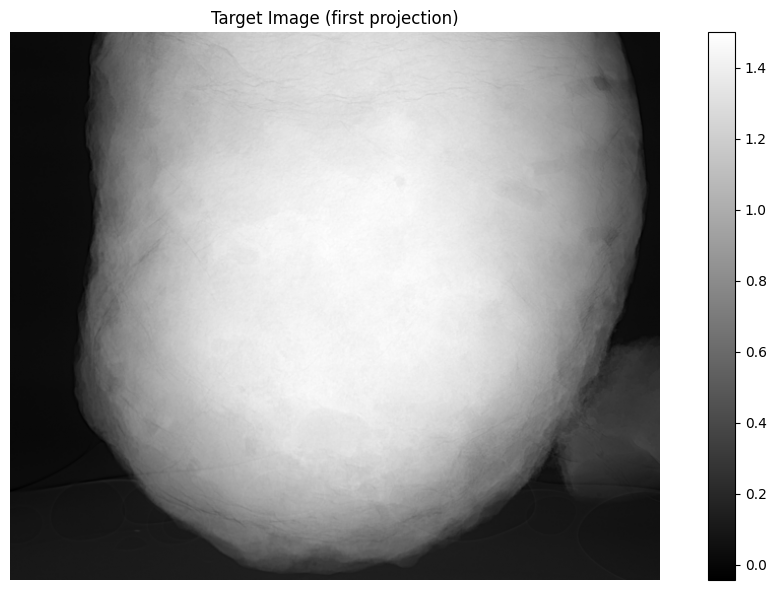

In [9]:
plt.figure(figsize=(10, 6))
plt.imshow(projections[100].cpu().numpy(), cmap='gray')
plt.title('Target Image (first projection)')
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

In [10]:
from tqdm import tqdm
from astra_torch.lamino import fbp_reconstruction_masked, gd_reconstruction_masked
# Reconstruction parameters
lamino_angle_deg = 0.0  # As specified in the request

def recosntruction_loop(projections, full_angles_deg, device):
    # Estimate volume shape based on projection size
    proj_height, proj_width = projections.shape[1], projections.shape[2]
    vol_shape = (proj_height, proj_width, proj_width)  # (nx, ny, nz)
    reconstructed_volume = None
    optimizer_state = None
    for _ in tqdm(range(20)):
        torch.cuda.empty_cache()
        reconstructed_volume, optimizer_state = gd_reconstruction_masked(
            projs_vrc=projections.to(device),
            angles_deg=full_angles_deg,
            vol_shape=vol_shape,
            device=device,
            lamino_angle_deg = 0,
            # max_epochs=[2],
            lr=[5e-3],
            batch_size=30,
            clamp_min=None,
            verbose=False,
            restart_optimizer=True,
            num_gd_steps = 30,
            vol_init=reconstructed_volume,
            optimizer_state=optimizer_state,
            return_optimizer_state=True,
        )
    return reconstructed_volume

In [ ]:
recons_shape = (projections.shape[1], projections.shape[2], projections.shape[2])  # (H, W)

# ── Full-angle FBP ─────────────────────────────────────────────────────────
gt_fbp = recosntruction_loop(projections, full_angles_deg, device)
print(f"GT FBP:         {gt_fbp.shape}  [{gt_fbp.min():.4f}, {gt_fbp.max():.4f}] ")
# ── Limited-angle FBP (middle frame only) ──────────────────────────────────

la_fbp = recosntruction_loop(la_projections, la_angles_deg, device)
print(f"LA FBP:         {la_fbp.shape}  [{la_fbp.min():.4f}, {la_fbp.max():.4f}] ")

  0%|          | 0/20 [00:00<?, ?it/s]

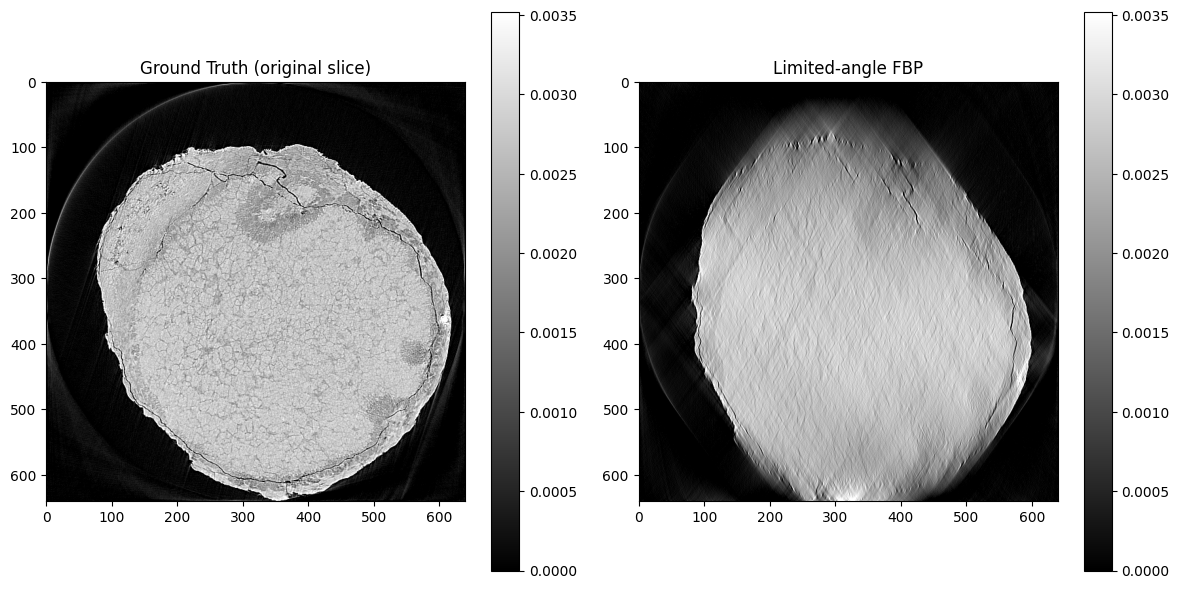

In [13]:
flat = gt_fbp.flatten()
flat_sampled = flat[torch.randperm(flat.numel())[:1_000_000]]
vmax = torch.quantile(flat_sampled, 0.99).item()  # Use 99th percentile to avoid outliers dominating the color scale

from chip.utils.utils import apply_circle_mask

TEST_SLICE_IDX = 100

vmin = 0
vmax = vmax

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow((gt_fbp)[TEST_SLICE_IDX].cpu().clip(0, 1), cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Ground Truth (original slice)')
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow((la_fbp[TEST_SLICE_IDX]).cpu().clip(0, 1), cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Limited-angle FBP')
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

In [14]:
import os
import json

PATH = f"/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction"
# make sure the directory exists
os.makedirs(PATH, exist_ok=True)

la_fbp_np = la_fbp.cpu().numpy()
gt_fbp_np = gt_fbp.cpu().numpy()


np.save(PATH + f"/la_fbp_{FILE_IDX}.npy", la_fbp_np)
np.save(PATH + f"/gt_fbp_{FILE_IDX}.npy", gt_fbp_np)

# Percentile-based normalisation range (1st–99th) so diffusion inputs ≈ [0, 1]
norm_min = float(np.percentile(la_fbp_np, 1))
norm_max = float(np.percentile(la_fbp_np, 99))
norm_config = {"norm_min": norm_min, "norm_max": norm_max}

norm_path = PATH + f"/la_fbp_{FILE_IDX}_norm.json"
with open(norm_path, "w") as _f:
    json.dump(norm_config, _f, indent=2)

print(f"Saved la_fbp  →  {PATH}/la_fbp_{FILE_IDX}.npy")
print(f"Saved gt_fbp  →  {PATH}/gt_fbp_{FILE_IDX}.npy")
print(f"Norm config   →  {norm_path}")
print(f"  norm_min (p1 ) = {norm_min:.4f}")
print(f"  norm_max (p99) = {norm_max:.4f}")


Saved la_fbp  →  /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fbp_1.npy
Saved gt_fbp  →  /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/gt_fbp_1.npy
Norm config   →  /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fbp_1_norm.json
  norm_min (p1 ) = -0.0009
  norm_max (p99) = 0.0034


# Fourier cone removal

In [2]:
import sys, importlib, json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path('/myhome/sdate')
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')

# ── Data loading ──────────────────────────────────────────────────────────
from inct.dataset_slices import ProjectionSliceDataset

# ── Reconstruction ────────────────────────────────────────────────────────
from astra_torch.lamino import gd_reconstruction_masked

# ── Diffusion model / pipeline ────────────────────────────────────────────
from diffusers.models import UNet2DModel
from ladiff.schedulers.scheduling_ddim import GuidedDDIMScheduler
from ladiff.schedulers.pipeline_ddim import DDIMPipeline

# ── Metrics ───────────────────────────────────────────────────────────────
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

import lovely_tensors as lt
lt.monkey_patch()

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")


Device: cuda  |  PyTorch 2.8.0+cu128
GPU: NVIDIA A100 80GB PCIe


In [3]:
FILE_IDX = 1

# ── Saved volume paths (output of Large_LA_Dataset) ───────────────────────
RECON_PATH = Path(f'/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction')
# LA_FBP_PATH  = RECON_PATH / f'la_fbp_{FILE_IDX}.npy'
GT_FBP_PATH  = RECON_PATH / f'gt_fbp_{FILE_IDX}.npy'
NORM_JSON    = RECON_PATH / f'la_fbp_{FILE_IDX}_norm.json'

# ── Inference ─────────────────────────────────────────────────────────────
NUM_INFERENCE_STEPS = 50

# ── Test slices: indices into the la_fbp volume (0 .. num_slices-1) ───────
# Set to None to test every TEST_STRIDE-th slice across the whole volume.
TEST_SLICE_INDICES = None   # e.g. [50, 100, 150] or None for automatic
TEST_STRIDE        = 20     # used when TEST_SLICE_INDICES is None

# ── Guidance hyperparams ──────────────────────────────────────────────────
GUIDANCE_MAX_EPOCHS = 5
GUIDANCE_LR         = 1e-3
GUIDANCE_BATCH_SIZE = 30

print("Configuration set ✅")


Configuration set ✅


In [4]:
gt_fbp = torch.tensor(np.load(GT_FBP_PATH))   # (num_slices, H, W)
# la_fbp = torch.tensor(np.load(LA_FBP_PATH))   # (num_slices, H, W)

print(f"gt_fbp shape : {gt_fbp.shape}  [{gt_fbp.min():.4f}, {gt_fbp.max():.4f}]")

gt_fbp

gt_fbp shape : torch.Size([540, 640, 640])  [-0.0502, 0.0402]


tensor[540, 640, 640] n=221184000 (0.8Gb) x∈[-0.050, 0.040] μ=0.001 σ=0.001

# Fourier Wedge Removal – Missing Wedge Simulation

Simulate limited-angle electron tomography by zeroing a 3-D wedge in Fourier space.

* **`TILT_AXIS`** controls which axis the sample rotates around: `0=kz`, `1=ky`, `2=kx`
* The missing wedge lives in the plane of the **other two axes**; all slices along the tilt axis share the same 2-D mask
* Kept angular range → `ANGULAR_RANGE_FRAC × 180°` degrees starting at `START_ANGLE`
* Friedel symmetry of real objects is enforced via `angle % 180°`

**Steps**
1. 3-D FFT of `gt_fbp`
2. Build the binary wedge mask (2-D in the wedge plane, broadcast over the tilt axis)
3. Visualise Fourier space before / after masking
4. Inverse FFT → `la_fourier_vol`
5. Save alongside `la_fbp`

In [ ]:
ANGULAR_RANGE_FRAC = 0.1

In [ ]:
import importlib
import ladiff.fourier_wedge as _fw_mod
importlib.reload(_fw_mod)

from ladiff.fourier_wedge import (
    build_missing_wedge_mask,
    apply_missing_wedge,
    inpaint_fourier_wedge,
    extract_central_slice_at_angle,
)

# ── Parameters ────────────────────────────────────────────────────────────────
ANGULAR_RANGE_DEG = int(ANGULAR_RANGE_FRAC * 180)   # 108 for ANGULAR_RANGE_FRAC=0.6
START_ANGLE       = (180 - ANGULAR_RANGE_DEG) // 2  # degrees; tilt starts here, runs to START_ANGLE + ANGULAR_RANGE_DEG
TILT_AXIS         = 0      # axis the sample rotates around: 0=kz  1=ky  2=kx

_AXIS_NAMES = {0: 'kz', 1: 'ky', 2: 'kx'}
assert TILT_AXIS in (0, 1, 2), "TILT_AXIS must be 0, 1, or 2"

# gt_fbp is a torch.Tensor; keep it on device for all downstream calls
vol = gt_fbp.float().to(device)   # (nz, ny, nx)
nz, ny, nx = vol.shape

print(f"Angular range : {ANGULAR_RANGE_DEG}°  (= {ANGULAR_RANGE_FRAC:.0%} × 180°)")
print(f"Kept range    : {START_ANGLE}° → {START_ANGLE + ANGULAR_RANGE_DEG}°")
print(f"Missing wedge : {180 - ANGULAR_RANGE_DEG}°")
print(f"Tilt axis     : {_AXIS_NAMES[TILT_AXIS]} (axis {TILT_AXIS})")
print(f"Volume shape  : {tuple(vol.shape)}  on device={vol.device}")

# ── Build mask & compute shifted FFT for visualisation ────────────────────────
mask_3d = build_missing_wedge_mask(
    tuple(vol.shape), ANGULAR_RANGE_DEG, START_ANGLE, TILT_AXIS, device=vol.device
)

vol_fft_shift = torch.fft.fftshift(torch.fft.fftn(vol))

_plane_axes = [a for a in range(3) if a != TILT_AXIS]
_pa0, _pa1  = _plane_axes
# 2-D slice of the mask at the tilt-axis midpoint
mask_2d = mask_3d.select(TILT_AXIS, vol.shape[TILT_AXIS] // 2)   # (shape[pa0], shape[pa1])

print(f"\nMask kept : {mask_2d.sum().item():,} / {mask_2d.numel():,}  "
      f"({mask_2d.float().mean().item()*100:.1f}%,  expected ≈{ANGULAR_RANGE_DEG/180*100:.1f}%)")

In [ ]:
# ── Fourier space visualisation ───────────────────────────────────────────────
import numpy as np   # numpy only used here for plotting helpers

def _get_slice_2d(arr3d, axis, idx):
    s = [slice(None)] * 3
    s[axis] = idx
    return arr3d[tuple(s)]

_a0n = _AXIS_NAMES[_pa0]
_a1n = _AXIS_NAMES[_pa1]
_tn  = _AXIS_NAMES[TILT_AXIS]

# Wedge-plane central slice (tensors → cpu numpy just for matplotlib)
_tilt_mid    = vol_fft_shift.shape[TILT_AXIS] // 2
_fft_wedge   = _get_slice_2d(vol_fft_shift, TILT_AXIS, _tilt_mid)
_mask_2d_np  = mask_2d.cpu().numpy()
_mag_wedge   = _fft_wedge.abs().cpu().numpy()
_log_mag     = np.log1p(_mag_wedge)
_log_masked  = np.log1p(_mag_wedge * _mask_2d_np)

# Plane containing the tilt axis
_pa0_mid        = vol_fft_shift.shape[_pa0] // 2
_fft_tilt_raw   = _get_slice_2d(vol_fft_shift, _pa0, _pa0_mid)
_remaining      = [a for a in range(3) if a != _pa0]
_tilt_pos       = _remaining.index(TILT_AXIS)
_pa1_pos        = _remaining.index(_pa1)
_fft_tilt_np    = _fft_tilt_raw.abs().cpu().numpy()
_fft_tilt_plane = _fft_tilt_np.T if _tilt_pos > _pa1_pos else _fft_tilt_np
_log_tilt       = np.log1p(_fft_tilt_plane)

_ext_wedge = [-vol.shape[_pa1]//2, vol.shape[_pa1]//2,
              -vol.shape[_pa0]//2, vol.shape[_pa0]//2]
_ext_tilt  = [-vol.shape[_pa1]//2, vol.shape[_pa1]//2,
              -vol.shape[TILT_AXIS]//2, vol.shape[TILT_AXIS]//2]

# frequency coords for radial power spectrum (cpu numpy, small)
_c0 = np.arange(vol.shape[_pa0], dtype=np.float32) - vol.shape[_pa0] // 2
_c1 = np.arange(vol.shape[_pa1], dtype=np.float32) - vol.shape[_pa1] // 2
_K0, _K1 = np.meshgrid(_c0, _c1, indexing='ij')

fig, axes_grid = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f"3-D Fourier space  ·  missing-wedge mask  (tilt axis = {_tn})", fontsize=14)

_im0 = axes_grid[0, 0].imshow(_log_mag, cmap='inferno', origin='lower', extent=_ext_wedge, aspect='auto')
axes_grid[0, 0].set_title(f'Log |FFT|  ({_a0n}–{_a1n},  {_tn}=0)')
axes_grid[0, 0].set_xlabel(_a1n);  axes_grid[0, 0].set_ylabel(_a0n)
plt.colorbar(_im0, ax=axes_grid[0, 0])

_im1 = axes_grid[0, 1].imshow(_mask_2d_np.astype(np.float32), cmap='RdBu_r', origin='lower',
                               extent=_ext_wedge, aspect='auto', vmin=0, vmax=1)
axes_grid[0, 1].set_title(f'Wedge mask  ({_a0n}–{_a1n})  — kept={ANGULAR_RANGE_DEG}°\n'
                           f'start={START_ANGLE}°   blue=missing  red=kept')
axes_grid[0, 1].set_xlabel(_a1n);  axes_grid[0, 1].set_ylabel(_a0n)
plt.colorbar(_im1, ax=axes_grid[0, 1])

_im2 = axes_grid[0, 2].imshow(_log_masked, cmap='inferno', origin='lower',
                               extent=_ext_wedge, aspect='auto')
axes_grid[0, 2].set_title(f'Log |FFT| after masking  ({_a0n}–{_a1n})')
axes_grid[0, 2].set_xlabel(_a1n);  axes_grid[0, 2].set_ylabel(_a0n)
plt.colorbar(_im2, ax=axes_grid[0, 2])

_im3 = axes_grid[1, 0].imshow(_log_tilt, cmap='inferno', origin='lower',
                               extent=_ext_tilt, aspect='auto')
axes_grid[1, 0].set_title(f'Log |FFT|  ({_tn}–{_a1n},  {_a0n}=0)\n(tilt axis → no wedge here)')
axes_grid[1, 0].set_xlabel(_a1n);  axes_grid[1, 0].set_ylabel(_tn)
plt.colorbar(_im3, ax=axes_grid[1, 0])

_im4 = axes_grid[1, 1].imshow(np.ones((vol.shape[TILT_AXIS], vol.shape[_pa1]), dtype=np.float32),
                               cmap='RdBu_r', origin='lower', extent=_ext_tilt, aspect='auto', vmin=0, vmax=1)
axes_grid[1, 1].set_title(f'Wedge mask  ({_tn}–{_a1n})\nall kept — no effect along tilt axis')
axes_grid[1, 1].set_xlabel(_a1n);  axes_grid[1, 1].set_ylabel(_tn)
plt.colorbar(_im4, ax=axes_grid[1, 1])

_r_2d  = np.sqrt(_K0**2 + _K1**2).ravel()
_bins  = np.linspace(0, max(vol.shape[_pa0]//2, vol.shape[_pa1]//2), 200)
_idx_r = np.digitize(_r_2d, _bins)
_p_full = np.array([_mag_wedge.ravel()[_idx_r == i].mean() if (_idx_r == i).any() else 0
                    for i in range(1, len(_bins))])
_p_mask = np.array([(_mag_wedge * _mask_2d_np).ravel()[_idx_r == i].mean() if (_idx_r == i).any() else 0
                    for i in range(1, len(_bins))])
axes_grid[1, 2].semilogy(_bins[:-1], _p_full, label='Full FFT', linewidth=1.5)
axes_grid[1, 2].semilogy(_bins[:-1], _p_mask, label=f'Masked ({ANGULAR_RANGE_DEG}°)', linewidth=1.5, linestyle='--')
axes_grid[1, 2].set_title(f'Radial power spectrum  ({_a0n}–{_a1n} central slice)')
axes_grid[1, 2].set_xlabel('Spatial frequency (pixels)');  axes_grid[1, 2].set_ylabel('Mean |FFT|')
axes_grid[1, 2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Apply missing wedge via API & save ───────────────────────────────────────
print("Applying missing wedge …")
la_fourier_vol = apply_missing_wedge(vol, ANGULAR_RANGE_DEG, START_ANGLE, TILT_AXIS)
# la_fourier_vol is a float32 tensor on `device`
print(f"la_fourier_vol : {tuple(la_fourier_vol.shape)}  "
      f"[{la_fourier_vol.min():.4f}, {la_fourier_vol.max():.4f}]  device={la_fourier_vol.device}")

import json

LA_FOURIER_PATH = RECON_PATH / f'la_fourier_{FILE_IDX}.npy'
LA_FOURIER_NORM = RECON_PATH / f'la_fourier_{FILE_IDX}_norm.json'

la_fourier_np = la_fourier_vol.cpu().numpy()
np.save(str(LA_FOURIER_PATH), la_fourier_np)

norm_min = float(np.percentile(la_fourier_np, 1))
norm_max = float(np.percentile(la_fourier_np, 99))
with open(str(LA_FOURIER_NORM), 'w') as _f:
    json.dump({"norm_min": norm_min, "norm_max": norm_max}, _f, indent=2)

print(f"\nSaved  →  {LA_FOURIER_PATH}")
print(f"Norm   →  {LA_FOURIER_NORM}")
print(f"  norm_min (p1 ) = {norm_min:.4f}")
print(f"  norm_max (p99) = {norm_max:.4f}")

In [ ]:
plt.imshow(la_fourier_vol[0].cpu())

In [ ]:
# ── Volume comparison: gt_fbp vs la_fourier_vol ───────────────────────────────
COMPARE_SLICES = [nz // 4, nz // 2, 3 * nz // 4]

vol_np = vol.cpu().numpy()
la_np  = la_fourier_vol.cpu().numpy()
_vmax  = float(np.percentile(vol_np, 99))

fig, axes = plt.subplots(len(COMPARE_SLICES), 3, figsize=(16, 5 * len(COMPARE_SLICES)))
fig.suptitle(f"GT FBP  vs  LA Fourier crop  ({ANGULAR_RANGE_DEG}° / 180°,  "
             f"start={START_ANGLE}°,  tilt={_AXIS_NAMES[TILT_AXIS]})", fontsize=13)

for row, sl in enumerate(COMPARE_SLICES):
    gt_sl = vol_np[sl]
    la_sl = la_np[sl]
    diff  = gt_sl - la_sl

    axes[row, 0].imshow(gt_sl, cmap='gray', vmin=0, vmax=_vmax)
    axes[row, 0].set_title(f'GT FBP  (z={sl})')
    axes[row, 0].axis('off')
    plt.colorbar(axes[row, 0].images[0], ax=axes[row, 0])

    _vmax_la = float(np.percentile(np.abs(la_sl), 99))
    axes[row, 1].imshow(la_sl, cmap='gray', vmin=0, vmax=_vmax_la)
    axes[row, 1].set_title(f'LA Fourier crop  (z={sl})')
    axes[row, 1].axis('off')
    plt.colorbar(axes[row, 1].images[0], ax=axes[row, 1])

    _vlim = float(np.percentile(np.abs(diff), 99))
    axes[row, 2].imshow(diff, cmap='RdBu_r', vmin=-_vlim, vmax=_vlim)
    axes[row, 2].set_title(f'Difference  (z={sl})')
    axes[row, 2].axis('off')
    plt.colorbar(axes[row, 2].images[0], ax=axes[row, 2])

plt.tight_layout()
plt.show()

print(f"\nFourier-cropped volume stats:")
print(f"  shape : {tuple(la_fourier_vol.shape)}")
print(f"  min / max : {la_fourier_vol.min():.4f} / {la_fourier_vol.max():.4f}")
print(f"  mean  : {la_fourier_vol.float().mean():.4f}  |  std : {la_fourier_vol.float().std():.4f}")

# Fourier Inpainting Demo

`inpaint_fourier_wedge(target, source, ...)` keeps the Fourier content of
**target** outside the missing wedge and fills the missing region with the
corresponding Fourier content taken from **source**.

Here we use `la_fourier_vol` (the wedge-corrupted GT) as the *target* and the
original `gt_fbp` volume as the *source* — a sanity check that should
approximately reconstruct the original volume.

We also show a more realistic scenario: using the LA-FBP reconstruction (produced
from real limited-angle projections) as the source, so the wedge region of the
diffusion / reconstruction output can be filled with real measurement data.

In [ ]:
# ── Scenario A: inpaint wedge of la_fourier_vol with gt_fbp (oracle check) ───
# Expected result ≈ gt_fbp  (the oracle source fills the gap perfectly)
inpainted_oracle = inpaint_fourier_wedge(
    target_volume    = la_fourier_vol.to(device),   # float32 tensor on device
    source_volume    = gt_fbp.to(device),              # oracle: original full-angle tensor on device
    angular_range_deg= ANGULAR_RANGE_DEG,
    start_angle_deg  = START_ANGLE,
    tilt_axis        = TILT_AXIS,
)
print(f"Inpainted (oracle) : {tuple(inpainted_oracle.shape)}  "
      f"[{inpainted_oracle.min():.4f}, {inpainted_oracle.max():.4f}]  device={inpainted_oracle.device}")

# ── Scenario B: inpaint wedge of la_fourier_vol with la_fbp (realistic) ──────
# la_fbp is the real limited-angle FBP reconstruction as a tensor
inpainted_lafbp = inpaint_fourier_wedge(
    target_volume    = la_fbp.to(device),
    source_volume    = gt_fbp.to(device),              # oracle: original full-angle tensor on devic
    angular_range_deg= ANGULAR_RANGE_DEG,
    start_angle_deg  = START_ANGLE,
    tilt_axis        = TILT_AXIS,
)
print(f"Inpainted (la_fbp) : {tuple(inpainted_lafbp.shape)}  "
      f"[{inpainted_lafbp.min():.4f}, {inpainted_lafbp.max():.4f}]  device={inpainted_lafbp.device}")

# ── Visualise three representative slices ─────────────────────────────────────
_vmax_gt = float(np.percentile(vol_np, 99))
_TEST_SLICES = [nz // 4, nz // 2, 3 * nz // 4]

# bring to cpu numpy once for plotting
_oracle_np = inpainted_oracle.cpu().numpy()
_lafbp_np  = inpainted_lafbp.cpu().numpy()

for _sl in _TEST_SLICES:
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(f"Fourier inpainting demo  (z={_sl},  {ANGULAR_RANGE_DEG}°,  "
                 f"tilt={_AXIS_NAMES[TILT_AXIS]})", fontsize=12)

    _panels = [
        (vol_np[_sl],          'GT FBP (reference)',       'gray',   0, _vmax_gt),
        (la_np[_sl],           'LA Fourier crop (target)', 'gray',   0, _vmax_gt),
        (_oracle_np[_sl],      'Inpainted (oracle src)',   'gray',   0, _vmax_gt),
        (_lafbp_np[_sl],       'Inpainted (la_fbp src)',   'gray',   0, _vmax_gt),
        (vol_np[_sl] - _oracle_np[_sl], 'Residual (oracle)', 'RdBu_r', None, None),
    ]

    for ax, (img, title, cmap, vmin, vmax) in zip(axes, _panels):
        if vmin is None:
            _lim = float(np.percentile(np.abs(img), 99))
            im = ax.imshow(img, cmap=cmap, vmin=-_lim, vmax=_lim)
        else:
            im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Real-Space Slices through the Missing Wedge

`extract_central_slice_at_angle(volume, angle_deg, tilt_axis)` extracts a 2-D
vertical cross-section through the centre of a 3-D volume.  The plane contains
the tilt axis and is oriented at `angle_deg` in the perpendicular plane, using
the same angle convention as the missing-wedge mask:

> **angle = atan2(K\_pa1, K\_pa0) % 180°**  (Friedel-symmetric)

**Interpretation in Fourier space:**
- A slice at an angle *inside* the kept range (**green**) would pass through
  the non-zero region of the FFT → the real-space slice looks like a normal
  cross-section.
- A slice at an angle *inside the missing wedge* (**red**) would pass entirely
  through the zeroed region → the real-space slice is blurred / streak-corrupted.

The comparison below shows both GT FBP and LA FBP to make the artefacts visible.

In [ ]:
# ── Select demonstration angles ───────────────────────────────────────────────
_n_demo = 3

# Angles evenly spaced INSIDE the measured (kept) range
_meas_step      = ANGULAR_RANGE_DEG / (_n_demo + 1)
measured_angles = [START_ANGLE + (i + 1) * _meas_step for i in range(_n_demo)]

# Angles evenly spaced INSIDE the missing wedge
_miss_range    = 180.0 - ANGULAR_RANGE_DEG
_miss_step     = _miss_range / (_n_demo + 1)
missing_angles = [
    (START_ANGLE + ANGULAR_RANGE_DEG + (i + 1) * _miss_step) % 180.0
    for i in range(_n_demo)
]

print(f"Measured angles : {[f'{a:.1f}°' for a in measured_angles]}")
print(f"Missing  angles : {[f'{a:.1f}°' for a in missing_angles]}")

# ── Extract slices from GT FBP and LA FBP ────────────────────────────────────
vol_la = la_fbp.float().to(device)   # limited-angle FBP on device

all_angles = measured_angles + missing_angles

gt_slices = [extract_central_slice_at_angle(vol,    θ, TILT_AXIS).cpu().numpy() for θ in all_angles]
la_slices = [extract_central_slice_at_angle(vol_la, θ, TILT_AXIS).cpu().numpy() for θ in all_angles]

# ── Plot ──────────────────────────────────────────────────────────────────────
_vmax_gt  = float(np.percentile(vol_np, 99))
_vmax_la  = float(np.percentile(vol_la.cpu().numpy(), 99))
_tilt_lbl = _AXIS_NAMES[TILT_AXIS]
_pa0_lbl  = _AXIS_NAMES[_pa0]
_pa1_lbl  = _AXIS_NAMES[_pa1]

_border_colors = ['#2ca02c'] * _n_demo + ['#d62728'] * _n_demo
_group_labels  = ['✓ measured'] * _n_demo + ['✗ missing'] * _n_demo

n_cols = len(all_angles)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 7.5),
                         gridspec_kw={'hspace': 0.08, 'wspace': 0.06})
fig.suptitle(
    f"Central vertical slices through the volume  (tilt axis = {_tilt_lbl})\n"
    f"Rows = GT FBP / LA FBP    ·    "
    f"Green border = measured ({ANGULAR_RANGE_DEG}°)    ·    "
    f"Red border = missing cone ({180 - ANGULAR_RANGE_DEG}°)",
    fontsize=12, y=1.02,
)

for col in range(n_cols):
    θ   = all_angles[col]
    clr = _border_colors[col]
    grp = _group_labels[col]

    for row, (slices, vmax, row_lbl) in enumerate([
        (gt_slices, _vmax_gt, 'GT FBP'),
        (la_slices, _vmax_la, 'LA FBP'),
    ]):
        ax = axes[row, col]
        ax.imshow(slices[col], cmap='gray', aspect='auto', vmin=0, vmax=vmax, origin='upper')
        ax.set_xticks([]);  ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(clr)
            spine.set_linewidth(3.5)

        if row == 0:
            ax.set_title(f"{θ:.1f}°\n({grp})", fontsize=9, color=clr, fontweight='bold')
        if col == 0:
            ax.set_ylabel(row_lbl, fontsize=10, labelpad=6)

axes[-1, 0].set_xlabel(f'← radial  ({_pa0_lbl}–{_pa1_lbl},  bilinear interp) →', fontsize=8)

plt.tight_layout()
plt.show()

# Extended Training Data: Vertical Slice Augmentation

The diffusion model is currently trained on **horizontal** slices (`vol[z, :, :]`).
To increase data volume and diversity, this section extracts ~1000 additional
**vertical** cross-sections from `la_fbp` — all at ≥70° from the x-y plane — and saves
them as a companion `.npy` file that `NpyVolumeSliceDataset` can load directly.

Three complementary slice types are extracted:

| Count | Type | Indexing | Pre-pad shape |
|------:|------|----------|---------------|
| 500 | **Axis-1** — xz views | `vol[:, y, :]` at random y | `(nz, nx)` |
| 250 | **Axis-2** — yz views | `vol[:, :, x]` at random x | `(nz, ny)` |
| 250 | **Azimuthal** — centred cuts | `extract_central_slice_at_angle(vol, θ, tilt_axis=0)` | `(nz, max(ny,nx))` |

All slices are **symmetrically zero-padded** to `(max_dim, max_dim)` so they match
the horizontal training slice size. The saved file reuses the `la_fbp` normalisation
sidecar so both files can be pointed to in the same training directory:
```
python train_large_ladiff.py --data_path /path/to/reconstruction/   # loads both .npy files
```

In [ ]:
import importlib, json
import torch.nn.functional as F
import ladiff.fourier_wedge as _fw_ext
importlib.reload(_fw_ext)
from ladiff.fourier_wedge import extract_central_slice_at_angle

# ── Config ────────────────────────────────────────────────────────────────────
_TILT_AXIS = 0          # matches the rest of the notebook
N_AX1      = 500        # axis-1 (xz) slices: vol[:, y, :]
N_AX2      = 500        # axis-2 (yz) slices: vol[:, :, x]
N_ANG      = 500        # centre-through slices at random azimuthal angles
N_TOT      = N_AX1 + N_AX2 + N_ANG   # 1000

# ── Volume reference ──────────────────────────────────────────────────────────
# la_fbp is (nz, ny, nx) — keep CPU copy for direct axis slicing (no overhead)
_vol_cpu = la_fbp.float()
_vol_gpu = la_fbp.float().to(device)   # for interpolated azimuthal slices
_nz, _ny, _nx = _vol_cpu.shape
_tgt = max(_nz, _ny, _nx)             # target square side (= ny = nx = 640)

print(f"Source volume  : {tuple(_vol_cpu.shape)}")
print(f"Target size    : {_tgt} × {_tgt}  "
      f"(vertical slices are ({_nz}, ·) → pad {_tgt - _nz} rows symmetrically)")
print(f"Slices to save : {N_AX1} axis-1  +  {N_AX2} axis-2  +  {N_ANG} azimuthal  =  {N_TOT}")


def _pad_square(t2d: torch.Tensor, side: int) -> torch.Tensor:
    """Symmetrically zero-pad a (H, W) CPU tensor to (side, side)."""
    h, w = t2d.shape
    ph, pw = side - h, side - w
    return F.pad(t2d, (pw // 2, pw - pw // 2, ph // 2, ph - ph // 2), value=0.0)


torch.manual_seed(42)

# ── Axis-1 slices: vol[:, y, :]  →  (nz, nx) ─────────────────────────────────
_y_pos   = torch.randint(100, 500, (N_AX1,)).tolist()
_ax1_slices = [_pad_square(_vol_cpu[:, y, :], _tgt) for y in _y_pos]
print(f"\nAxis-1  done  {N_AX1} × {tuple(_ax1_slices[0].shape)}")

# ── Axis-2 slices: vol[:, :, x]  →  (nz, ny) ─────────────────────────────────
_x_pos   = torch.randint(100, 500, (N_AX2,)).tolist()
_ax2_slices = [_pad_square(_vol_cpu[:, :, x], _tgt) for x in _x_pos]
print(f"Axis-2  done  {N_AX2} × {tuple(_ax2_slices[0].shape)}")

# ── Azimuthal centre-through slices ───────────────────────────────────────────
_thetas  = (torch.rand(N_ANG) * 180.0).tolist()
_ang_slices = [
    _pad_square(
        extract_central_slice_at_angle(_vol_gpu, θ, _TILT_AXIS).cpu(),
        _tgt,
    )
    for θ in _thetas
]
print(f"Azimuthal done  {N_ANG} × {tuple(_ang_slices[0].shape)}")

# ── Stack, convert, save ──────────────────────────────────────────────────────
vert_slices_np = (
    torch.stack(_ax1_slices + _ax2_slices + _ang_slices)
    .numpy()
    .astype(np.float32)
)   # (N_TOT, _tgt, _tgt)

VERT_NPY  = RECON_PATH / f'la_fbp_{FILE_IDX}_vert.npy'
VERT_NORM = RECON_PATH / f'la_fbp_{FILE_IDX}_vert_norm.json'

np.save(str(VERT_NPY), vert_slices_np)

# Reuse the la_fbp normalisation range so both datasets stay on the same scale
try:
    with open(str(NORM_JSON)) as _f:
        _la_norm = json.load(_f)
    _vn_min, _vn_max = float(_la_norm['norm_min']), float(_la_norm['norm_max'])
    print(f"\nNorm   : reused from {NORM_JSON.name}  [{_vn_min:.4f}, {_vn_max:.4f}]")
except (FileNotFoundError, KeyError):
    _vn_min = float(np.percentile(vert_slices_np, 1))
    _vn_max = float(np.percentile(vert_slices_np, 99))
    print(f"\nNorm   : computed from data  [{_vn_min:.4f}, {_vn_max:.4f}]")

with open(str(VERT_NORM), 'w') as _f:
    json.dump({"norm_min": _vn_min, "norm_max": _vn_max}, _f, indent=2)

print(f"Shape  : {vert_slices_np.shape}  "
      f"[{vert_slices_np.min():.4f}, {vert_slices_np.max():.4f}]")
print(f"Saved  : {VERT_NPY}")
print(f"Norm   : {VERT_NORM}")
print(f"\nTraining usage (directory mode — loads both files automatically):")
print(f"  NpyVolumeSliceDataset('{RECON_PATH}')  "
      f"→ {_nz * ny * nx // (ny * nx) + N_TOT} slices total")

In [ ]:
# ── Preview: 4 representative samples from each slice category ────────────────
_N_PER_ROW = 4
_vmax_p    = float(np.percentile(vert_slices_np, 99))

_preview_idx_ax1 = np.linspace(0, N_AX1 - 1, _N_PER_ROW, dtype=int)
_preview_idx_ax2 = np.linspace(0, N_AX2 - 1, _N_PER_ROW, dtype=int)
_preview_idx_ang = np.linspace(0, N_ANG - 1, _N_PER_ROW, dtype=int)

_rows = [
    ('Axis-1  (xz view)\nvol[:, y, :]',       _ax1_slices, _preview_idx_ax1,
     [f"y = {_y_pos[i]}" for i in _preview_idx_ax1],  '#2ca02c'),
    ('Axis-2  (yz view)\nvol[:, :, x]',       _ax2_slices, _preview_idx_ax2,
     [f"x = {_x_pos[i]}" for i in _preview_idx_ax2],  '#1f77b4'),
    ('Azimuthal\nextract_central_slice_at_angle', _ang_slices, _preview_idx_ang,
     [f"θ = {_thetas[i]:.1f}°" for i in _preview_idx_ang],  '#d62728'),
]

fig, axes = plt.subplots(3, _N_PER_ROW, figsize=(5 * _N_PER_ROW, 4.5 * 3),
                         gridspec_kw={'hspace': 0.28, 'wspace': 0.04})
fig.suptitle(
    f"Vertical slice augmentation preview  —  {N_TOT} slices  "
    f"saved to  {VERT_NPY.name}\n"
    f"Volume ({_nz}, {_ny}, {_nx})  →  each slice padded to ({_tgt}, {_tgt})",
    fontsize=12, y=1.01,
)

for row_idx, (row_label, slices_list, idxs, subtitles, clr) in enumerate(_rows):
    for col_idx, (si, subtitle) in enumerate(zip(idxs, subtitles)):
        ax = axes[row_idx, col_idx]
        ax.imshow(slices_list[si].numpy(), cmap='gray',
                  aspect='auto', vmin=0, vmax=_vmax_p, origin='upper')
        ax.set_title(subtitle, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(clr)
            spine.set_linewidth(2.5)
        if col_idx == 0:
            ax.set_ylabel(row_label, fontsize=9, labelpad=8)

plt.tight_layout()
plt.show()

print(f"Dataset breakdown:")
print(f"  Horizontal slices (la_fbp_{FILE_IDX}.npy) : {_nz} slices  →  ({_ny}, {_nx}) each")
print(f"  Vertical slices   (la_fbp_{FILE_IDX}_vert.npy) : {N_TOT} slices  →  ({_tgt}, {_tgt}) each")
print(f"  Combined (directory mode)               : {_nz + N_TOT} slices")

# Sliding Window FBP (SW-FBP) — Time-Resolved Volume Simulation

Generates the **data_path** volume for `iterative_isonet_time_resolved_pipeline.py`.

**Acquisition model**: each axial slice `i` (along `tilt_axis`) measures only the angular
range `[START_ANGLE_DEG + i × ALPHA_DEG, START_ANGLE_DEG + (i+1) × ALPHA_DEG)` (mod 180°)
in 2-D Fourier space — matching the `TimeResolvedVolumes` dataset mask.

**SW-FBP**: to reconstruct slice `i` from a full 180°, we borrow the measured wedges from
`n_total = round(180 / ALPHA_DEG)` consecutive slices centred as closely as possible on `i`
(`n_before = n_total // 2` slices before, `n_after = n_total − 1 − n_before` after).
Boundary slices use a clamped (off-centre) window of the same width.

Each contributing slice `j` provides its own 2-D FFT masked to its `ALPHA_DEG`-wide wedge;
the wedges are disjoint and together span exactly 180°. Inverse FFT gives the SW-FBP slice.

In [28]:
# ── SW-FBP parameters ─────────────────────────────────────────────────────────
ALPHA_DEG       = 18.0   # angular range measured per slice (degrees); 180 / ALPHA_DEG must be an integer
START_ANGLE_DEG = 0.0    # starting angle for slice 0 (degrees)
TILT_AXIS_SW    = 0      # axis along which slices are stacked (must match TimeResolvedVolumes)

# ── Derived window geometry ───────────────────────────────────────────────────
assert 180.0 % ALPHA_DEG < 1e-9, f"180 / ALPHA_DEG must be an integer, got {180/ALPHA_DEG:.6f}"
n_total  = round(180.0 / ALPHA_DEG)   # total frames needed to cover 180°
n_before = n_total // 2               # frames borrowed before current slice  (floor)
n_after  = n_total - 1 - n_before     # frames borrowed after  current slice  (ceil for even n_total)

print(f"ALPHA_DEG       : {ALPHA_DEG}°")
print(f"START_ANGLE_DEG : {START_ANGLE_DEG}°")
print(f"n_total         : {n_total}  (window width in frames, covers 180°)")
print(f"n_before        : {n_before}  (frames borrowed before current slice)")
print(f"n_after         : {n_after}  (frames borrowed after  current slice)")
print(f"\nWindow for interior slice i : [i-{n_before}, …, i, …, i+{n_after}]")
print(f"  → {'symmetric' if n_before == n_after else 'asymmetric (extra frame after)'}")

ALPHA_DEG       : 18.0°
START_ANGLE_DEG : 0.0°
n_total         : 10  (window width in frames, covers 180°)
n_before        : 5  (frames borrowed before current slice)
n_after         : 4  (frames borrowed after  current slice)

Window for interior slice i : [i-5, …, i, …, i+4]
  → asymmetric (extra frame after)


In [29]:
import sys
sys.path.insert(0, '/myhome/sdate')

from tqdm import tqdm
from isodiffusion.fourier_wedge import _build_mask_2d_torch

_vol = gt_fbp.float().to(device)   # (N, ny, nx)
N, ny, nx = _vol.shape

# ── Step 1: precompute masked FFTs (one per slice, each stores only its own wedge) ──
# masked_fft[j] = FFT(gt_fbp[j]) * mask_j  — stored on CPU to save GPU memory.
# Note: _build_mask_2d_torch forces mask[ny//2, nx//2]=True so that DC is included
# in every mask. To avoid summing DC n_total times we zero it out here and add back
# the current slice's DC in Step 2.
print(f"Precomputing {N} masked FFTs  ({ny}×{nx}, {ALPHA_DEG}° wedge each) …")
masked_ffts = []
dc_values   = []   # DC component per slice, saved separately
for j in tqdm(range(N), desc="masked FFT"):
    start_j = (START_ANGLE_DEG + j * ALPHA_DEG) % 180.0
    mask_j  = _build_mask_2d_torch(ny, nx, ALPHA_DEG, start_j, device)   # bool (ny, nx)
    fft_j   = torch.fft.fftshift(torch.fft.fft2(_vol[j]))                # complex64 (ny, nx)
    dc_values.append(fft_j[ny // 2, nx // 2].cpu())
    fft_j[ny // 2, nx // 2] = 0          # exclude DC; will be added back in Step 2
    masked_ffts.append((fft_j * mask_j).cpu())

# ── Step 2: assemble SW-FBP by summing n_total consecutive masked wedges ─────────
# DC is not in the masked FFTs; we add back the current slice's own DC so the
# mean intensity of sw_fbp[i] matches gt_fbp[i] rather than the window average.
print(f"\nAssembling SW-FBP  (window = {n_total} frames, {n_before} before / {n_after} after) …")
sw_fbp_slices = []
for i in tqdm(range(N), desc="SW-FBP"):
    i_start = max(0, min(i - n_before, N - n_total))
    window  = range(i_start, i_start + n_total)

    combined_fft = sum(masked_ffts[j].to(device) for j in window)   # complex64 (ny, nx)
    combined_fft[ny // 2, nx // 2] = dc_values[i].to(device)        # restore current slice DC

    sw_slice = torch.fft.ifft2(torch.fft.ifftshift(combined_fft)).real
    sw_fbp_slices.append(sw_slice.cpu())

sw_fbp = torch.stack(sw_fbp_slices)   # (N, ny, nx)
print(f"\nsw_fbp shape : {tuple(sw_fbp.shape)}  [{sw_fbp.min():.4f}, {sw_fbp.max():.4f}]")
print(f"gt_fbp range : [{gt_fbp.min():.4f}, {gt_fbp.max():.4f}]")

Precomputing 540 masked FFTs  (640×640, 18.0° wedge each) …


masked FFT: 100%|██████████| 540/540 [00:01<00:00, 458.95it/s] 



Assembling SW-FBP  (window = 10 frames, 5 before / 4 after) …


SW-FBP: 100%|██████████| 540/540 [00:02<00:00, 246.82it/s]



sw_fbp shape : (540, 640, 640)  [-0.0492, 0.0413]
gt_fbp range : [-0.0502, 0.0402]


/tmp/ipykernel_3108908/3338142152.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


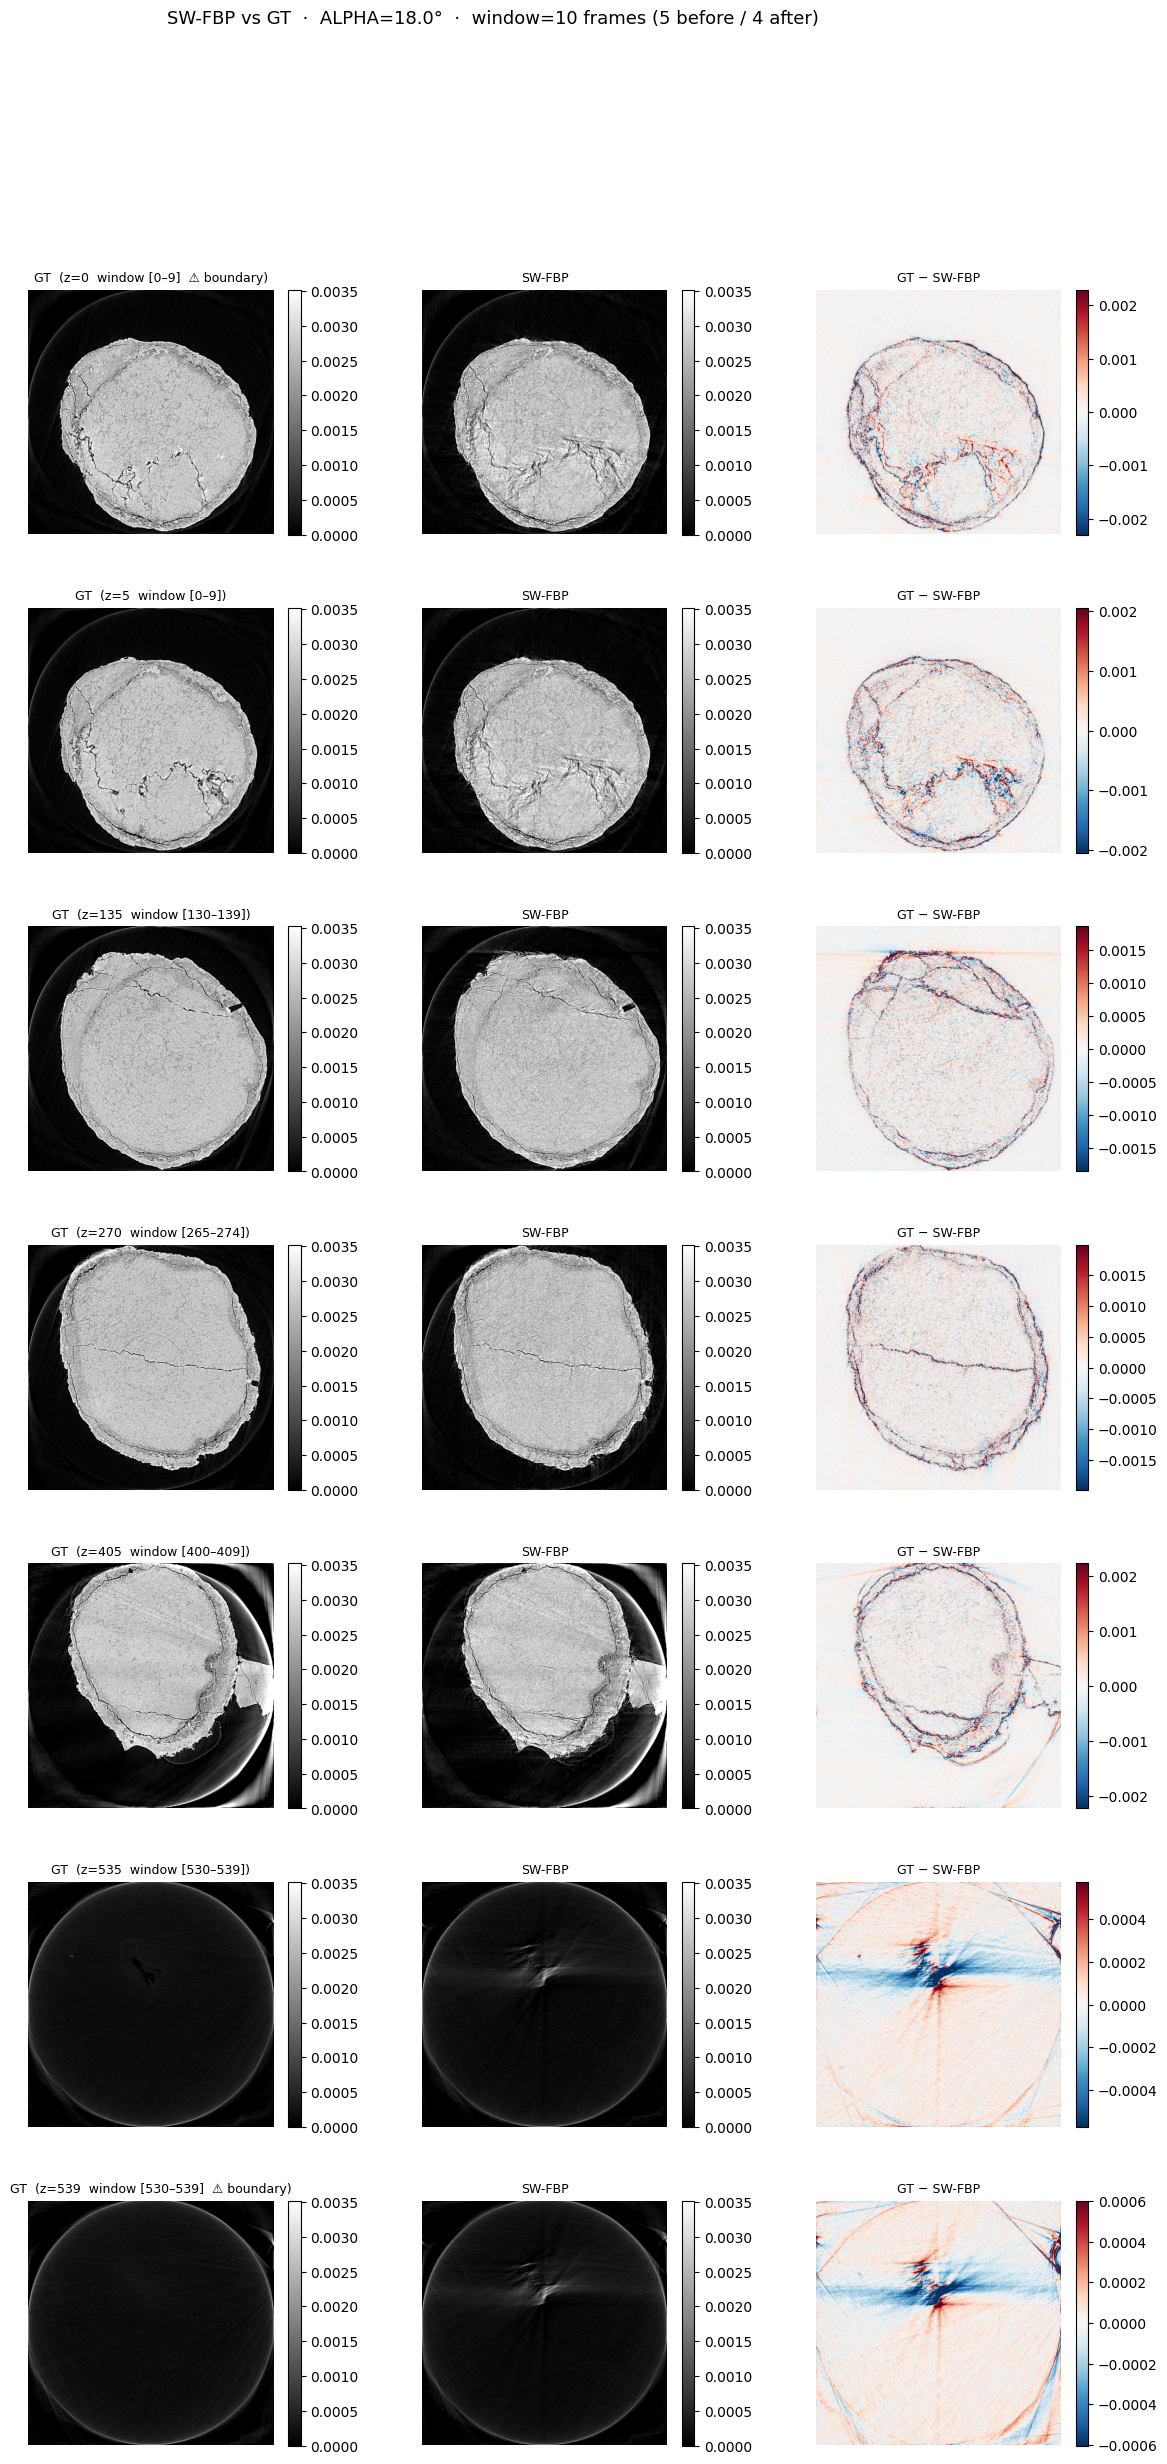

Window positions for selected slices:
  slice    0: window [   0–   9]  (current slice at pos 1/10, centre offset -5 frames)
  slice    5: window [   0–   9]  (current slice at pos 6/10, centre offset +0 frames)
  slice  135: window [ 130– 139]  (current slice at pos 6/10, centre offset +0 frames)
  slice  270: window [ 265– 274]  (current slice at pos 6/10, centre offset +0 frames)
  slice  405: window [ 400– 409]  (current slice at pos 6/10, centre offset +0 frames)
  slice  535: window [ 530– 539]  (current slice at pos 6/10, centre offset +0 frames)
  slice  539: window [ 530– 539]  (current slice at pos 10/10, centre offset +4 frames)


In [30]:
# ── Visualise: GT vs SW-FBP at a few representative slices ───────────────────
_gt_np   = gt_fbp.cpu().numpy()
_sw_np   = sw_fbp.numpy()
_vmax_vis = float(np.percentile(_gt_np, 99))

# Pick slices: boundary, near-boundary, and interior
_test_slices = sorted({
    0,                          # first (most off-centre window)
    n_before,                   # first fully-interior slice
    N // 4,
    N // 2,
    3 * N // 4,
    N - 1 - n_after,            # last fully-interior slice
    N - 1,                      # last
})
_test_slices = [s for s in _test_slices if 0 <= s < N]

fig, axes = plt.subplots(len(_test_slices), 3,
                         figsize=(15, 4 * len(_test_slices)),
                         gridspec_kw={'hspace': 0.3, 'wspace': 0.05})
fig.suptitle(
    f"SW-FBP vs GT  ·  ALPHA={ALPHA_DEG}°  ·  window={n_total} frames "
    f"({n_before} before / {n_after} after)",
    fontsize=13,
)

for row, sl in enumerate(_test_slices):
    i_start  = max(0, min(sl - n_before, N - n_total))
    win_info = f"window [{i_start}–{i_start + n_total - 1}]"
    boundary = sl < n_before or sl >= N - n_after
    label    = f"z={sl}  {win_info}" + ("  ⚠ boundary" if boundary else "")

    gt_sl = _gt_np[sl]
    sw_sl = _sw_np[sl]
    diff  = gt_sl - sw_sl
    _dlim = float(np.percentile(np.abs(diff), 99))

    for ax, (img, title, cmap, vmin, vmax) in zip(axes[row], [
        (gt_sl, f"GT  ({label})",    "gray",    0,      _vmax_vis),
        (sw_sl,  "SW-FBP",           "gray",    0,      _vmax_vis),
        (diff,   "GT − SW-FBP",      "RdBu_r",  -_dlim, _dlim),
    ]):
        im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
        ax.set_title(title, fontsize=9)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ── Summarise window positions ────────────────────────────────────────────────
print("Window positions for selected slices:")
for sl in _test_slices:
    i_start = max(0, min(sl - n_before, N - n_total))
    offset  = sl - (i_start + n_before)   # 0 = perfectly centred
    print(f"  slice {sl:4d}: window [{i_start:4d}–{i_start+n_total-1:4d}]  "
          f"(current slice at pos {sl - i_start + 1}/{n_total}, "
          f"centre offset {offset:+d} frames)")

In [31]:
import json, os

SW_FBP_PATH = RECON_PATH / f'sw_fbp_{FILE_IDX}.npy'
SW_FBP_NORM = RECON_PATH / f'sw_fbp_{FILE_IDX}_norm.json'

sw_fbp_np = sw_fbp.numpy().astype(np.float32)
np.save(str(SW_FBP_PATH), sw_fbp_np)

norm_min = float(np.percentile(sw_fbp_np, 1))
norm_max = float(np.percentile(sw_fbp_np, 99))
with open(str(SW_FBP_NORM), 'w') as _f:
    json.dump({
        "norm_min":        norm_min,
        "norm_max":        norm_max,
        "alpha_deg":       ALPHA_DEG,
        "start_angle_deg": START_ANGLE_DEG,
        "cone_width_deg":  180.0 - ALPHA_DEG,
        "n_total":         n_total,
        "n_before":        n_before,
        "n_after":         n_after,
    }, _f, indent=2)

print(f"Saved  →  {SW_FBP_PATH}")
print(f"Norm   →  {SW_FBP_NORM}")
print(f"  norm_min (p1 ) = {norm_min:.4f}")
print(f"  norm_max (p99) = {norm_max:.4f}")
print()
print("Use as data_path for the time-resolved iterative pipeline:")
print(f"  --data_path      {SW_FBP_PATH}")
print(f"  --cone_width_deg {180.0 - ALPHA_DEG}")
print(f"  --start_angle_deg {START_ANGLE_DEG}")

Saved  →  /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/sw_fbp_1.npy
Norm   →  /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/sw_fbp_1_norm.json
  norm_min (p1 ) = -0.0016
  norm_max (p99) = 0.0036

Use as data_path for the time-resolved iterative pipeline:
  --data_path      /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/sw_fbp_1.npy
  --cone_width_deg 162.0
  --start_angle_deg 0.0
